In [1]:
import os


os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DEDUP_LOGS"] = "1"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from starforge.blackholes.parameters_recover.parameters_recovery import ParametersRecoveryRemote
from starforge.blackholes.parameters_recover.metrics import (
    nrmse_percent,
    smape_percent,
    stabilized_mape_percent,
)
from starforge.blackholes.accretionrate.blackholesaccretionrate import ParameterAccretionRate
from starforge.blackholes.parameters_recover.utils import add_noise_to_data, gaussian_sum_from_p
from starforge.blackholes.parameters_recover.utils import make_bounds_for_gaussians
from starforge.blackholes.parameters_recover.schemes import GridParameters
import ray

In [3]:
if ray.is_initialized() is False:
    ray.init(ignore_reinit_error=True)

2026-05-21 13:53:40,356	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8267 


In [4]:
mbh_steps = 25

grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps*100
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

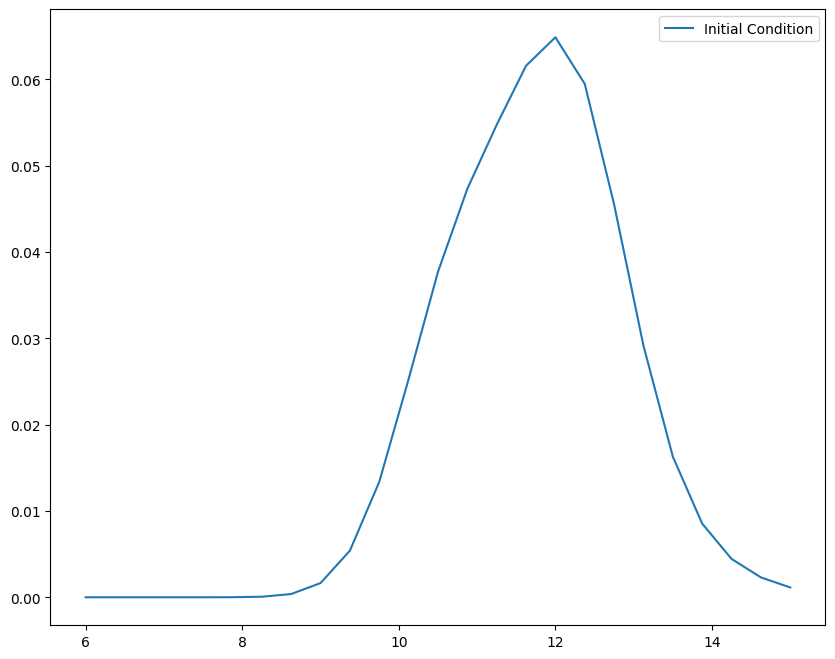

In [5]:
parameters_observational = np.array([
        3.3e-02,
        8.2e-03,
        5.4e-02,
        1.07e+01,
        1.29e+01,
        1.21e+01,
        6.93e-01,
        1.05e+00,
        7.47e-01
    ])


initial_condition = gaussian_sum_from_p(
        parameters_observational,
        ln_mbh_grid,
        n_gauss=3
    )

plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, initial_condition, label="Initial Condition")
# plt.yscale("log")
plt.legend()
plt.show()
plt.close()

In [6]:
objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params)

accretion_params = ParameterAccretionRate(
    mbh_par=2e11,
    alpha_par=3e-1,
    tau_par=5e9,
    eta=0.1,
    t_q=1e9,
    b_1=0.1,
    b_2=0.1,
)


# ---- Generate target data ----

outputs = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        accretion_params
    )
)


In [7]:
# Noise levels to evaluate
noise_levels = [0.01, 0.03, 0.05, 0.1]

# Dictionary to store all runs
results = {}

In [ ]:
    # ---- Define bounds for optimization ----

bounds = make_bounds_for_gaussians(
    x_min=6.0,
    x_max=15.0,
    preferred_center_index=2,
    preferred_center=12.0,
    preferred_center_radius=1.0,
    Amax=1e-1,
    sigma_min=0.01,
    sigma_max=5.0,
    sigma_max_preferred=1.0,
    K=3
)


bounds.extend([  # For eta, tau_par, alpha_par
    (0.5, 5.0),     # mbh_par
    (1.0, 10.0),   # tau_par Gyr
    (0.01, 0.6),    # alpha_par
    (0.01, 0.5),    # eta
    (0.5, 5.0),    # t_q Gyr
    (0.01, 0.5),   # b_1
    (0.01, 0.5)    # b_2
])


MODEL_PARAM_COUNT = 7

for i, noise_level in enumerate(noise_levels):

    target_data = add_noise_to_data(
        data=outputs.n_final,
        mu=0.0,
        sigma=noise_level,
        rho=0.5,
        alpha=0.5,
        seed=52+i,
        noise_type='mixed'
    )
    # -------------------------------------------------
    
    result = ray.get(
        objective_function.optimizer.remote(
            bounds=bounds,
            target_data=target_data,
            weight_p=0.01,
            weight_theta=0.01,
            fast_mode=False,
            use_de=True
        )
    )

    best_params = result.x

    gaussian_parameters = best_params[:-MODEL_PARAM_COUNT]
    model_parameters = best_params[-MODEL_PARAM_COUNT:]


    initial_condition_recovered = gaussian_sum_from_p(
            gaussian_parameters,
            ln_mbh_grid,
            n_gauss=3
        )  

    # Build physical model parameters
    accretion_params_recovered = ParameterAccretionRate(
        mbh_par=model_parameters[0] * 1e11,
        tau_par=model_parameters[1] * 1e9,
        alpha_par=model_parameters[2],

        eta=model_parameters[3],
        t_q=model_parameters[4] * 1e9,
        b_1=model_parameters[5],
        b_2=model_parameters[6]
    )

    # ---- Generate target data ----

    outputs_recovery = ray.get(
        objective_function.directly_problem.remote(
            initial_condition_recovered,
            accretion_params_recovered
        )
    )

    # -------------------------------------------------

    recovered_initial_condition = initial_condition_recovered

    recovered_output = outputs_recovery.n_final

    target_data = np.clip(target_data, 1e-30, None)
    recovered_output = np.clip(recovered_output, 1e-30, None)
    recovered_initial_condition = np.clip(
        recovered_initial_condition,
        1e-30,
        None
    )

    # -------------------------------------------------
    # Initial Condition Metrics
    # -------------------------------------------------

    nrmse_init = nrmse_percent(
        initial_condition,
        recovered_initial_condition,
        denom='mean'
    )

    s_mape_init = smape_percent(
        initial_condition,
        recovered_initial_condition,
        eps=1e-12
    )

    stab_mape_init = stabilized_mape_percent(
        initial_condition,
        recovered_initial_condition,
        eps=1e-8
    )

    # -------------------------------------------------
    # Final Condition Metrics
    # -------------------------------------------------

    nrmse = nrmse_percent(
        target_data,
        recovered_output,
        denom='mean'
    )

    s_mape = smape_percent(
        target_data,
        recovered_output,
        eps=1e-12
    )

    stab_mape = stabilized_mape_percent(
        target_data,
        recovered_output,
        eps=1e-8
    )

    # -------------------------------------------------
    # Metrics text
    # -------------------------------------------------

    metrics_text_init = (
        f'NRMSE={nrmse_init:.2f}%\n'
        f'sMAPE={s_mape_init:.2f}%\n'
        f'MAPE*={stab_mape_init:.2f}%'
    )

    metrics_text = (
        f'NRMSE={nrmse:.2f}%\n'
        f'sMAPE={s_mape:.2f}%\n'
        f'MAPE*={stab_mape:.2f}%'
    )

    # -------------------------------------------------
    # Store results
    # -------------------------------------------------

    results[noise_level] = {
        "ln_mbh_grid": ln_mbh_grid,
        "initial_condition": initial_condition,
        "initial_condition_recovered": recovered_initial_condition,
        "outputs_n_final": recovered_output,
        "target_data": target_data,
        "metrics": metrics_text,
        "metrics_init": metrics_text_init,
        "grid_params": grid_params,
    }

(ParametersRecovery pid=624164) Starting optimization ...
(ParametersRecovery pid=624164) Objective value: 1.493052e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=624164) Objective value: 1.447150e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=624164) Objective value: 1.437374e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=624164) Objective value: 1.432994e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=624164) Objective value: 1.402703e+02 | Context: Minimum detected in annealing process


(ParametersRecovery pid=624164) /home/eduardo/Projects/starforge2/.venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
(ParametersRecovery pid=624164)   df = [f_eval - f0 for f_eval in f_evals]


(ParametersRecovery pid=624164) Objective value: 1.375657e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=624164) Objective value: 1.349696e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=624164) Objective value: 1.281763e+02 | Context: Minimum detected in annealing process


In [ ]:
# Optional: article-style plotting configuration
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "lines.linewidth": 2,
    "axes.grid": True,
})

In [ ]:
# =====================================================
# Initial Conditions Comparison
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 16))

axes = axes.flatten()

for i, noise in enumerate(sorted(results.keys())):

    ax = axes[i]
    res = results[noise]

    ax.plot(
        res['ln_mbh_grid'],
        res['initial_condition'],
        marker='o',
        markersize=4,
        linestyle='None',
        label='Original Initial Condition',
        color='blue'
    )

    ax.plot(
        res['ln_mbh_grid'],
        res['initial_condition_recovered'],
        '--',
        label='Recovered Initial Condition',
        color='black'
    )

    ax.set_yscale('log')

    ax.set_xlabel(r'$\log(M_{BH} / M_{\odot})$')
    ax.set_ylabel(r'$n$ [dex$^{-1}$]')

    ax.text(
        0.97,
        0.05,
        res['metrics_init'],
        transform=ax.transAxes,
        fontsize=10,
        va='bottom',
        ha='right',
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.8
        )
    )

    ax.set_title(
        rf'Initial Conditions at $z = {res["grid_params"].z_i}$'
        '\n'
        rf'Noise = {noise*100:.0f}\%'
    )

    ax.legend()

plt.tight_layout()

# Optional:
plt.savefig("./images/initial_conditions_comparison.pdf", bbox_inches="tight")

plt.show()

In [ ]:
# =====================================================
# Final Data Comparison
# =====================================================

fig2, axes2 = plt.subplots(2, 2, figsize=(18, 16))

axes2 = axes2.flatten()

for i, noise in enumerate(sorted(results.keys())):

    ax2 = axes2[i]
    res = results[noise]

    ax2.plot(
        res['ln_mbh_grid'],
        res['outputs_n_final'],
        '--',
        label='Recovered',
        color='black'
    )

    ax2.plot(
        res['ln_mbh_grid'],
        res['target_data'],
        marker='o',
        markersize=4,
        linestyle='None',
        label=rf'Target Data ({noise*100:.1f}\% Noise)',
        color='blue'
    )

    ax2.set_yscale('log')

    ax2.set_xlabel(r'$\log(M_{BH} / M_{\odot})$')
    ax2.set_ylabel(r'$n$ [dex$^{-1}$]')

    ax2.text(
        0.97,
        0.05,
        res['metrics'],
        transform=ax2.transAxes,
        fontsize=10,
        va='bottom',
        ha='right',
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.8
        )
    )

    ax2.set_title(
        rf'Final Distribution at $z = {res["grid_params"].z_f}$ '
        '\n'
        rf'Noise = {noise*100:.0f}\%'
    )

    ax2.legend()

plt.tight_layout()

# Optional:
plt.savefig("./images/final_distribution_comparison.pdf", bbox_inches="tight")

plt.show()

In [ ]:
ray.shutdown()